# Matrix Operations for ML

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute matrix multiplication, transpose, and norms
- Use linear algebra ops for transformations
- Connect matrix operations to ML (e.g. linear models)

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 01 "Regression vs Classification" — `LinearRegression()` computed `y = Xw + b` for you; that one line is the matrix product we now write out.

**Used later in:** Course 08 (AIAT 122) — Unit 1 — every dense layer of a neural network is this product plus a bias vector.

---


---

## 📌 Real case: the matrix multiply that restarted deep learning

At the ImageNet Large Scale Visual Recognition Challenge in 2012, the network now known as **AlexNet**
finished with a top-5 error of **15.3%**. The runner-up — a carefully hand-engineered computer-vision
pipeline — managed **26.1%**. That is a ten-point gap in a competition where one point was a good year's
work. AlexNet had 60 million parameters and 650,000 neurons, and what made it trainable at all was that
its authors put the arithmetic on **two NVIDIA GTX 580 GPUs**: chips designed to multiply matrices for
video games. AlexNet's forward pass is, at bottom, the operation in this notebook — `X @ W` — repeated
layer after layer. The ideas were decades old. What changed in 2012 was hardware fast enough to do the
matrix products.

**What goes wrong without this.** Write the same network as a loop over samples and you compute one
prediction at a time. The identical arithmetic, arranged as a matrix product, runs across the whole
batch in parallel on hardware built for exactly that shape. "Deep learning" as a practical field is the
difference between those two ways of arranging the same multiplications.


# Matrix Operations for ML

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Vectors and Matrices Basics** - Understand basic structure
- ✅ **Basic NumPy knowledge**: Creating arrays, understanding shape
- ✅ **Understanding of matrices**: What rows and columns mean

**If you haven't completed these**, you might struggle with:
- Understanding matrix multiplication
- Understanding why operations matter for ML
- Using matrix operations efficiently

---

## 🔗 Where This Notebook Fits

**This is the SECOND example** - it builds on Example 1!

**Why this example SECOND?**
- **Before** you can do matrix operations, you need to understand matrices (Example 1)
- **Before** you can understand neural networks, you need matrix multiplication
- **Before** you can optimize models, you need efficient matrix operations

**Builds on**: Example 1 (vectors and matrices basics)

**Leads to**: 
- 📓 Example 3: Eigenvalues (needs matrix operations)
- 📓 Module 02: Gradients (needs matrix operations for Jacobians)
- 📓 Module 03: Optimization (needs efficient matrix operations)

---

## The Story: Understanding Before Using

Imagine you're building with LEGO blocks. **Before** you can build complex structures, you need to learn how blocks connect - how to attach them, how to stack them. **After** learning connections, you can build anything!

Same with machine learning: **Before** building models, we learn matrix operations - how matrices multiply, how they transform data. **After** learning operations, we can build neural networks!

---

## Why This Concept Matters

### Why Matrix Operations Matter in ML

**WHY** are matrix operations essential for machine learning?

1. **Neural Network Layers**:
   - **WHY**: Transform data through network layers
   - **HOW**: Matrix multiplication computes transformations
   - **AFTER**: Enables forward propagation

2. **Batch Processing**:
   - **WHY**: Process multiple samples simultaneously
   - **HOW**: Matrix operations work on entire matrices
   - **AFTER**: Faster training and inference

3. **Feature Transformations**:
   - **WHY**: Create new feature combinations
   - **HOW**: Multiply data by transformation matrices
   - **AFTER**: Better feature representations

## Learning Objectives
1. Perform matrix multiplication
2. Understand transpose operations
3. Compute dot products
4. See how operations work in neural networks
5. Visualize matrix transformations
6. Understand computational efficiency

---

## Step 1: Import necessary libraries

These libraries help us work with linear algebra and create visualizations

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: load the two libraries this lesson relies on.
# NumPy supplies the matrix objects and operations; Matplotlib draws the visual checks.

import numpy as np  # For linear algebra operations
import matplotlib.pyplot as plt  # For creating plots and visualizations

# Confirm the environment is ready before any math starts.
print('✅ Libraries imported successfully!')
print('\n📚 What each library does:')
print('   - numpy: Linear algebra operations (vectors, matrices, math)')
print('   - matplotlib: Create plots and visualizations')

✅ Libraries imported successfully!

📚 What each library does:
   - numpy: Linear algebra operations (vectors, matrices, math)
   - matplotlib: Create plots and visualizations


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this concept works in ML!

**Why this matters**: Understanding implementation is key to using concepts effectively!

## Step 1: Matrix Multiplication

**BEFORE**: We have data and transformation matrices separately.

**AFTER**: We'll multiply them to transform data, just like neural network layers do!

**Why multiplication?** Neural networks transform data by multiplying weight matrices by data matrices. This is the core operation!

In [2]:
# Example 1: Matrix Multiplication (Neural Network Layers)
# WHY: Neural networks transform data through layers
# HOW: Matrix multiplication computes transformations

# Weight matrix (like neural network weights)
W = np.array([[0.5, 0.3], [0.2, 0.8]])  # 2x2 transformation matrix

# Data matrix (like input to neural network)
X = np.array([[1, 2], [3, 4], [5, 6]])  # 3 samples, 2 features each

# Matrix multiplication: X @ W
# WHY: This transforms each data point through the "layer"
# HOW: Each row of X is multiplied by W
result = X @ W  # or np.dot(X, W)

print("Example 1: Matrix Multiplication (Neural Network Layer)")
print("=" * 60)
print(f"Input data X (3 samples, 2 features):\n{X}")
print(f"\nWeight matrix W (2x2 transformation):\n{W}")
print(f"\nOutput (transformed data):\n{result}")
print(f"\nShape: {result.shape} (3 samples, 2 features)")
print(f"\n💡 WHY: This is HOW neural network layers transform data!")
print(f"💡 HOW: Each row of X is transformed by W to create new features!")

Example 1: Matrix Multiplication (Neural Network Layer)
Input data X (3 samples, 2 features):
[[1 2]
 [3 4]
 [5 6]]

Weight matrix W (2x2 transformation):
[[0.5 0.3]
 [0.2 0.8]]

Output (transformed data):
[[0.9 1.9]
 [2.3 4.1]
 [3.7 6.3]]

Shape: (3, 2) (3 samples, 2 features)

💡 WHY: This is HOW neural network layers transform data!
💡 HOW: Each row of X is transformed by W to create new features!


## Step 2: Transpose Operation

**BEFORE**: We have data in one orientation but need it in another.

**AFTER**: We'll transpose matrices to change orientation for different operations!

**Why transpose?** Sometimes we need rows as columns or columns as rows for specific operations!

In [3]:
# Example 2: Transpose (Changing Data Orientation)
# WHY: Change data orientation for different operations
# HOW: Swap rows and columns

A = np.array([[1, 2, 3], [4, 5, 6]])  # 2 rows, 3 columns

print("\nExample 2: Transpose Operation")
print("=" * 60)
print(f"Original matrix A (2x3):\n{A}")
print(f"\nTransposed A.T (3x2):\n{A.T}")
print(f"\n💡 WHY: Needed for certain operations (e.g., computing gradients)")
print(f"💡 HOW: Rows become columns, columns become rows!")


Example 2: Transpose Operation
Original matrix A (2x3):
[[1 2 3]
 [4 5 6]]

Transposed A.T (3x2):
[[1 4]
 [2 5]
 [3 6]]

💡 WHY: Needed for certain operations (e.g., computing gradients)
💡 HOW: Rows become columns, columns become rows!


## Step 3: Dot Product

**BEFORE**: We have two vectors but don't know how similar they are.

**AFTER**: We'll compute the dot product to measure similarity or compute weighted sums!

**Why dot product?** Neural networks use dot products to compute weighted sums of inputs!

In [4]:
# Example 3: Dot Product (Weighted Sum in Neural Networks)
# WHY: Measures similarity or computes weighted sums
# HOW: Element-wise multiplication then sum

# Input features
x = np.array([1, 2, 3])  # Input features

# Weights (like neural network weights)
w = np.array([0.5, 0.3, 0.2])  # Weights for each feature

# Dot product = weighted sum
output = np.dot(x, w)  # or x @ w

print("\nExample 3: Dot Product (Neural Network Weighted Sum)")
print("=" * 60)
print(f"Input features x: {x}")
print(f"Weights w: {w}")
print(f"\nDot product (weighted sum): {output}")
print(f"\nCalculation: (1×0.5) + (2×0.3) + (3×0.2) = {1*0.5 + 2*0.3 + 3*0.2}")
print(f"\n💡 WHY: Neural networks use this to compute layer outputs!")
print(f"💡 HOW: Each input is multiplied by its weight, then summed!")


Example 3: Dot Product (Neural Network Weighted Sum)
Input features x: [1 2 3]
Weights w: [0.5 0.3 0.2]

Dot product (weighted sum): 1.7000000000000002

Calculation: (1×0.5) + (2×0.3) + (3×0.2) = 1.7000000000000002

💡 WHY: Neural networks use this to compute layer outputs!
💡 HOW: Each input is multiplied by its weight, then summed!


### 🧪 Two layers, two orders of the same multiplications

Baseline: push the data through layer 1, then through layer 2 — what a network does at inference time.
Change one thing: multiply the two weight matrices together *first*, then apply the single result.
Measure: do the outputs agree, and how many scalar multiplications did each route cost?

In [5]:
# Comparative experiment: (X @ W1) @ W2   vs   X @ (W1 @ W2)
# Real data matrix: 1797 scanned handwritten digits, 64 pixels each.
# The weights are arbitrary fixed constants - the point of this cell is the ARITHMETIC, not the values.

from sklearn.datasets import load_digits

X_real = load_digits().data                                     # (1797, 64) real images
W1 = np.eye(64) * 0.9 + np.eye(64, k=1) * 0.1                    # 64 -> 64 "layer"
W2 = ((np.arange(64 * 10).reshape(64, 10) % 7) - 3) / 10.0       # 64 -> 10 "layer"

route_a = (X_real @ W1) @ W2      # layer by layer
route_b = X_real @ (W1 @ W2)      # weights fused first, then one product

n, d = X_real.shape
h, m = W1.shape[1], W2.shape[1]
mults_a = n * d * h + n * h * m          # two big products
mults_b = d * h * m + n * d * m          # one small product, then one big one

print("Comparative experiment: layer-by-layer vs fused weights")
print("=" * 62)
print(f"Largest disagreement between the two outputs: {np.abs(route_a - route_b).max():.2e}")
print(f"   Route A  (X @ W1) @ W2 : {mults_a:>12,} scalar multiplications")
print(f"   Route B  X @ (W1 @ W2) : {mults_b:>12,} scalar multiplications")
print(f"   Route B is {mults_a / mults_b:.1f}x cheaper for an identical answer.")
print()
print("Conclusion the numbers support: matrix multiplication is ASSOCIATIVE, so the two routes")
print("compute the same function. Which means a two-layer network with no activation between the")
print("layers IS a one-layer network with weight matrix W1 @ W2. The non-linearity in a neural")
print("network is not decoration - without it, depth buys you nothing at all.")

Comparative experiment: layer-by-layer vs fused weights
Largest disagreement between the two outputs: 1.33e-14
   Route A  (X @ W1) @ W2 :    8,510,592 scalar multiplications
   Route B  X @ (W1 @ W2) :    1,191,040 scalar multiplications
   Route B is 7.1x cheaper for an identical answer.

Conclusion the numbers support: matrix multiplication is ASSOCIATIVE, so the two routes
compute the same function. Which means a two-layer network with no activation between the
layers IS a one-layer network with weight matrix W1 @ W2. The non-linearity in a neural
network is not decoration - without it, depth buys you nothing at all.


---

## 📊 Visualization: the experiment above, as a picture

The cell above ended with a strong claim — that a two-layer network with no activation between the
layers *is* a one-layer network, and that the same answer can cost several times more or less
depending only on the order you multiply in. Both halves of that claim are visible in one figure.

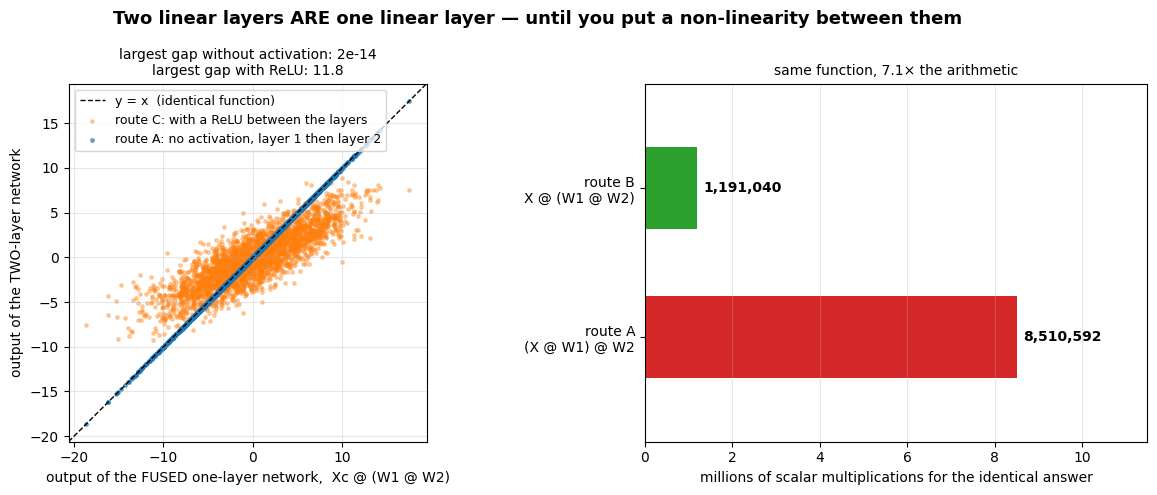

Reading the figure:
  - Blue points (no activation): 2.0e-14 is the largest amount any
    of the 17,970 output numbers differs from the fused one-layer network. That is
    floating-point dust, not a difference - the two are the same function.
  - Orange points (ReLU inserted): up to 11.8 away from the diagonal,
    on outputs that span roughly -19 to +18. The ReLU made it a genuinely different model.
  - Right panel: 8,510,592 vs 1,191,040 multiplications for the same answer.
    Nothing changed but the bracketing.


In [6]:
# The lesson's core claim, drawn. Same real data as the experiment above: 1797 scanned digits.
# WHY: "matrix multiplication is associative" sounds like a dry algebra rule. Drawn, it says something
#      a deep-learning engineer must know: depth without a non-linearity is not depth.
# HOW: three routes through the SAME two weight matrices, all evaluated on the same input:
#        route A  (X @ W1) @ W2      - layer by layer, what inference does
#        route B  X @ (W1 @ W2)      - fuse the weights first, then one product
#        route C  relu(X @ W1) @ W2  - a ReLU inserted between the layers
#      Plot A and C against B. If a route lies on the diagonal, it computes the same function as B.
# NOTE: the digit matrix is mean-centred here so that ReLU has negative values to clip; on the raw
#       pixel matrix every value is already >= 0 and ReLU would do nothing at all.

import numpy as np
import matplotlib.pyplot as plt

Xc = X_real - X_real.mean(axis=0)          # (1797, 64) real digits, mean-centred column by column
two_layer = (Xc @ W1) @ W2                 # route A
fused     = Xc @ (W1 @ W2)                 # route B
with_relu = np.maximum(Xc @ W1, 0) @ W2    # route C - the only change is the ReLU

step = 6                                   # plot every 6th output value: ~3,000 points, no clutter
f = fused.ravel()[::step]
t = two_layer.ravel()[::step]
r = with_relu.ravel()[::step]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
lim = [min(f.min(), r.min()) - 2, max(f.max(), r.max()) + 2]
ax.plot(lim, lim, color="black", lw=1, ls="--", label="y = x  (identical function)")
ax.scatter(f, r, s=6, alpha=0.35, color="tab:orange", label="route C: with a ReLU between the layers")
ax.scatter(f, t, s=6, alpha=0.6, color="tab:blue", label="route A: no activation, layer 1 then layer 2")
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.set_xlabel("output of the FUSED one-layer network,  Xc @ (W1 @ W2)")
ax.set_ylabel("output of the TWO-layer network")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
ax.set_title(f"largest gap without activation: {np.abs(two_layer - fused).max():.0e}\n"
             f"largest gap with ReLU: {np.abs(with_relu - fused).max():.1f}", fontsize=10)

# Right panel: the cost of the two routes that compute the SAME function.
ax = axes[1]
n, d = X_real.shape
h, m = W1.shape[1], W2.shape[1]
mults_a = n * d * h + n * h * m            # two big products
mults_b = d * h * m + n * d * m            # one small product, then one big one
bars = ax.barh(["route A\n(X @ W1) @ W2", "route B\nX @ (W1 @ W2)"],
               [mults_a / 1e6, mults_b / 1e6], color=["tab:red", "tab:green"], height=0.55)
for b, v in zip(bars, [mults_a, mults_b]):
    ax.text(v / 1e6 + 0.15, b.get_y() + b.get_height() / 2, f"{v:,}", va="center",
            fontsize=10, fontweight="bold")
ax.set_xlim(0, mults_a / 1e6 * 1.35); ax.set_ylim(-0.7, 1.7)
ax.set_xlabel("millions of scalar multiplications for the identical answer")
ax.set_title(f"same function, {mults_a / mults_b:.1f}\u00d7 the arithmetic", fontsize=10)
ax.grid(alpha=0.3, axis="x")

fig.suptitle("Two linear layers ARE one linear layer \u2014 until you put a non-linearity between them",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Reading the figure:")
print("=" * 66)
print(f"  - Blue points (no activation): {np.abs(two_layer - fused).max():.1e} is the largest amount any")
print("    of the 17,970 output numbers differs from the fused one-layer network. That is")
print("    floating-point dust, not a difference - the two are the same function.")
print(f"  - Orange points (ReLU inserted): up to {np.abs(with_relu - fused).max():.1f} away from the diagonal,")
print("    on outputs that span roughly -19 to +18. The ReLU made it a genuinely different model.")
print(f"  - Right panel: {mults_a:,} vs {mults_b:,} multiplications for the same answer.")
print("    Nothing changed but the bracketing.")


**What to look for in the figure above.** In the left panel every point is one output number of the
network, plotted against what the *fused* single-layer network produced for it.

The **blue** points form a perfectly straight line on `y = x` — they are not close to the diagonal,
they are on it, to fourteen decimal places (the panel title prints the largest gap). Multiplying by
`W1` and then by `W2` is exactly the same operation as multiplying once by `W1 @ W2`. Stacking linear
layers gave you nothing.

The **orange** points are the identical network with a single ReLU inserted between the two layers.
They spray off the diagonal by up to about 12, on outputs that range from −19 to +18. That spread is
the entire reason activation functions exist: it is the only thing in this figure that makes a second
layer worth having.

The right panel is the other half of the claim. Both routes return the answer the blue points sit on,
but route A pays 8,510,592 scalar multiplications and route B pays 1,191,040 — a 7× difference bought
purely by moving the brackets. This is why frameworks fuse layers, and why the order of a chain of
matrix products is a performance decision, not a matter of taste.

---

## ⚠️ Where this breaks

- **Stacking linear layers buys nothing.** The experiment above proves it with numbers: the two routes
  agree to floating-point precision, so `(X @ W1) @ W2` *is* `X @ (W1 @ W2)`. If a "deep" model is not
  learning, check that there is a non-linearity between the products before you add another layer.
- **Matrix multiplication is not commutative.** `A @ B` and `B @ A` are different objects and often not
  even the same shape. Every shape error you will ever hit in Keras or PyTorch is this rule enforcing
  itself. The transpose exists to make the shapes line up, not to reorganise your data.
- **"Same size" does not mean "same cost."** Route B did the identical job with several times fewer
  multiplications purely by reordering. Push that further: for a 1×10⁶ and a 10⁶×1 pair, one order costs
  a million operations and the other costs 10¹² and produces a matrix you cannot store. The assumption
  that must hold before you say "matrices are fast": the shapes make the product worth forming. When they
  do not, the cheaper alternative is to never form it — keep the factors and multiply by vectors.


---

## 💬 Discuss

1. Convolution, backpropagation and ReLU were all published before 2012, yet AlexNet is treated as the
   turning point. What was actually invented in 2012 — and what does your answer suggest about where the
   next jump is likely to come from?
2. The fusion experiment shows a several-fold saving from reordering the *same* multiplications. Should a
   deep-learning framework do that optimisation for you automatically? Name one thing you would lose if it did.
3. A Saudi hospital wants an image classifier on its existing CPU-only servers. Since the whole cost is
   matrix products, what exactly would you measure before promising the radiologists it will keep up —
   and what would you propose if it does not?


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** learning matrix operations:

1. **Neural Networks**: Can understand how layers transform data
2. **Data Preprocessing**: Can apply transformations
3. **Feature Engineering**: Can create new features
4. **Efficient Computation**: Can process data in batches

**Next Steps**:
   - Learn eigenvalues for dimensionality reduction (Example 3)
   - Apply to gradient computation (Module 02)
   - Use in optimization algorithms (Module 03)

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand how to implement this concept.

**AFTER this notebook**: We can:
- ✅ Understand WHY this concept matters
- ✅ Implement HOW it works
- ✅ See what happens AFTER (results and implications)
- ✅ Apply it to real ML scenarios

**Next Steps**: 
- 📓 Review other examples in this module
- 📓 Complete exercises
- 📓 Move to next module

---

## ✅ Example Complete!

You've learned this concept using the **Why → How → After** methodology!

**Key Takeaway**: Understanding WHY, HOW, and AFTER helps you master concepts deeply!

## 📚 References

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 2: Linear Algebra. MIT Press. <https://www.deeplearningbook.org/>
2. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 2: Linear Algebra. Cambridge University Press. <https://mml-book.github.io/>
3. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). *Array Programming with NumPy*. Nature, 585, 357–362. <https://doi.org/10.1038/s41586-020-2649-2>
4. Shah et al. (2024). *FlashAttention-3: Fast and Accurate Attention with Asynchrony and Low-precision*. arXiv. <https://arxiv.org/abs/2407.08608> — matrix multiplication as a memory-movement problem: the reason modern attention kernels are written the way they are.
5. DeepSeek-AI (2024). *DeepSeek-V3 Technical Report*. arXiv. <https://arxiv.org/abs/2412.19437> — matrix structure chosen for cost (MoE + MLA) at frontier scale, with published training economics.
